This notebook conducts enrichment analysis and creates plots of the relative risk of each variant type for expression outliers.

This notebook should take about a minute to run.

## Setup

In [1]:
library(ggplot2)
library(data.table)

In [2]:
collapsed <- fread('collapsed.tsv')

## Functions

In [3]:
# Relative Risk stats calculation
rr <- function(anno, exclude_genes_with_anno=c(), z_thresh=3) {
  genes <- collapsed[collapsed[, rowSums(.SD)>0, .SDcols=patterns(anno)], unique(GeneName)]
  if(length(exclude_genes_with_anno)>0) {
    genes2exclude <- collapsed[collapsed[, rowSums(.SD)>0, .SDcols=exclude_genes_with_anno], unique(GeneName)]
    genes <- setdiff(genes,genes2exclude)
  }

   is_outlier <- collapsed[GeneName %in% genes, abs(z)>z_thresh]
  has_variant <- collapsed[GeneName %in% genes, rowSums(.SD)>0, .SDcols=patterns(anno)]

  TT <- sum( is_outlier &  has_variant)
  TF <- sum( is_outlier & !has_variant)
  FT <- sum(!is_outlier &  has_variant)
  FF <- sum(!is_outlier & !has_variant)

  rr <- (TT/(TT+TF)) / (FT/(FT+FF))
  se <- sqrt(1/TT - 1/(TT+TF) + 1/FT - 1/(FT+FF))
  lo <- exp(log(rr)-1.96*se)
  hi <- exp(log(rr)+1.96*se)
  p  <- fisher.test(matrix(c(TT,TF,FT,FF),nrow=2))$p.value

  data.table(`SNV Type`=paste(collapse='|',anno), `Z threshold`=z_thresh, RR=rr, RR_lo=lo,RR_hi=hi, p, TT=TT)
}

In [4]:
plot_rr <- function(data) {
  ggplot(data, aes(x=`Z threshold`, y=RR, color=`SNV Type`)) + 
    geom_errorbar(aes(ymin=RR_lo, ymax=RR_hi, group=`SNV Type`), color='black', width=0,linewidth=0.10, position=position_dodge(width=0.4)) +
    geom_line(position=position_dodge(width=0.4)) +
    geom_point(position=position_dodge(width=0.4), size=2.5) +
    labs(title="Relative Risk vs Z-score Threshold", x="Threshold", y="Relative Risk") +
    theme_bw() +
    geom_hline(yintercept=1,linetype='dashed') +
    xlab('Outlier z-score threshold') +
    coord_cartesian(ylim = c(0.8, 8))
}


## Define annotations to be plotted

In [5]:
annos <- c(
  `Non-coding`      = 'non_coding_transcript_variant|non_coding_transcript_exon_variant',
  Synonymous        = 'synonymous_variant',
  Missense          = 'missense_variant',
  Stop              = 'stop_gained',
  TSS               = '5_prime_UTR_variant',
  `Splice region`   = 'splice_region_variant',
  `Splice acceptor` = 'splice_acceptor_variant',
  `Splice donor`    = 'splice_donor_variant')
excluded_annos <- list(
  c('splice_acceptor_variant','splice_donor_variant','splice_region_variant','stop_gained','missense_variant','synonymous_variant'),
  c('splice_acceptor_variant','splice_donor_variant','splice_region_variant','stop_gained','missense_variant'),
  c('splice_acceptor_variant','splice_donor_variant','splice_region_variant','stop_gained'),
  c('splice_acceptor_variant','splice_donor_variant','splice_region_variant'),
  c('splice_acceptor_variant','splice_donor_variant','splice_region_variant'),
  c(),
  c(),
  c()
)
runs <- CJ(thresh=seq(1,4,1), annos, sorted=F) |> cbind(excluded_annos)

head(runs)

thresh,annos,excluded_annos
<dbl>,<chr>,<list>
1,non_coding_transcript_variant|non_coding_transcript_exon_variant,"splice_acceptor_variant, splice_donor_variant , splice_region_variant , stop_gained , missense_variant , synonymous_variant"
1,synonymous_variant,"splice_acceptor_variant, splice_donor_variant , splice_region_variant , stop_gained , missense_variant"
1,missense_variant,"splice_acceptor_variant, splice_donor_variant , splice_region_variant , stop_gained"
1,stop_gained,"splice_acceptor_variant, splice_donor_variant , splice_region_variant"
1,5_prime_UTR_variant,"splice_acceptor_variant, splice_donor_variant , splice_region_variant"
1,splice_region_variant,NULL


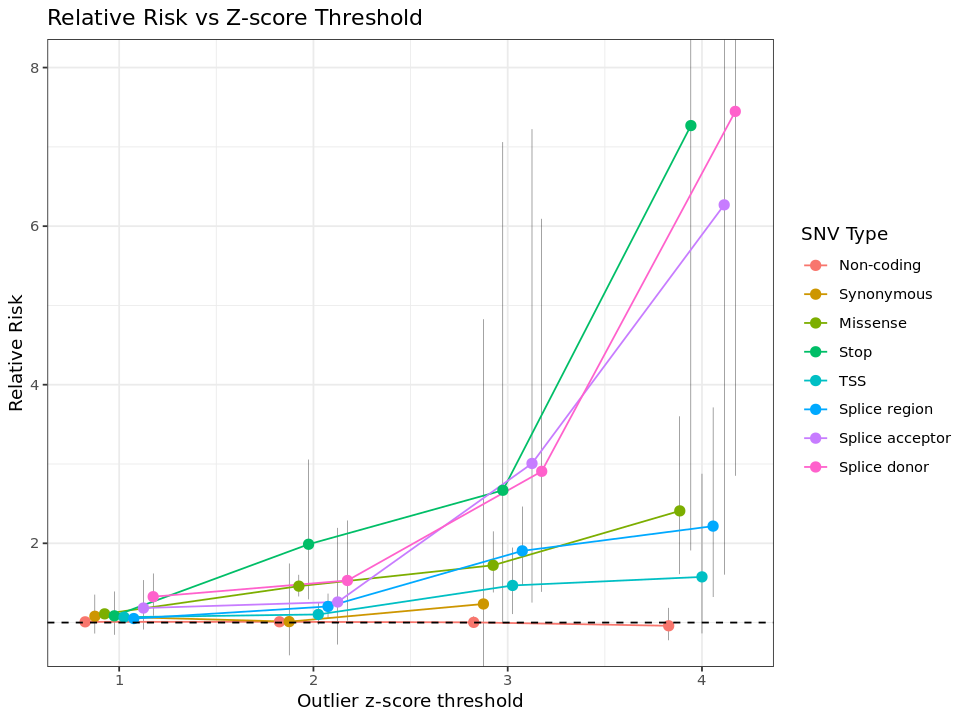

In [6]:
options(repr.plot.width = 8, repr.plot.height = 6)

rbindlist( Map(runs$annos, runs$excluded_annos, runs$thresh, f=\(a,ex,t) rr(a,ex,t)) )[
  ][, `SNV Type` := factor(`SNV Type`, levels=annos, labels=names(annos))
  ][TT>0
]|> plot_rr()

This plot should show the relative risk vs Z score threshold, color-coded for the annotation type. We expect to see higher-severity outliers more enriched for higher-severity classes of SNV.